# 02 — Signal Computation

Compute D1–D4 signals on BTC and ETH DVOL. Visualise signal events and characterise their timing.

In [1]:
import sys
sys.path.append('..')

import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from src.deribit_fetch import load_dvol, compute_iv_features
from src.signals import compute_all, signal_summary

cfg = yaml.safe_load(open('../config.yaml'))
sig_cfg = cfg['signals']
plt.rcParams['figure.figsize'] = (14, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

## 1. Build Features and Compute Signals

In [2]:
from pathlib import Path

def build_features(currency: str) -> pd.DataFrame:
    dvol = load_dvol(currency)
    rvol_path = Path(f'../data/deribit/{currency.upper()}_rvol_computed.parquet')
    rvol = pd.read_parquet(rvol_path) if rvol_path.exists() else None
    feat = compute_iv_features(dvol, rvol)
    feat['dvol_high'] = dvol['high']
    feat['dvol_low'] = dvol['low']
    return feat

btc_feat = build_features('BTC')
eth_feat = build_features('ETH')

btc_sigs = compute_all(btc_feat, sig_cfg)
eth_sigs = compute_all(eth_feat, sig_cfg)

print('BTC Signal Summary:')
print(signal_summary(btc_sigs))
print()
print('ETH Signal Summary:')
print(signal_summary(eth_sigs))

BTC Signal Summary:
    bullish (+1)  bearish (-1)  total
D1           352           206    558
D2            80            31    111
D3           495           404    899
D4           347           207    554

ETH Signal Summary:
    bullish (+1)  bearish (-1)  total
D1           334           193    527
D2            74            15     89
D3           494           412    906
D4           332           188    520


## 2. Visualise Signals on DVOL

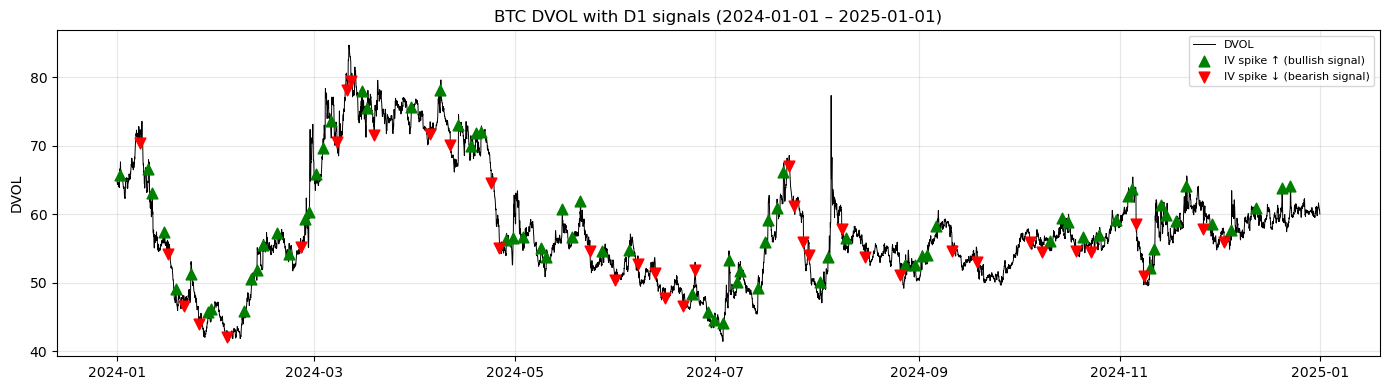

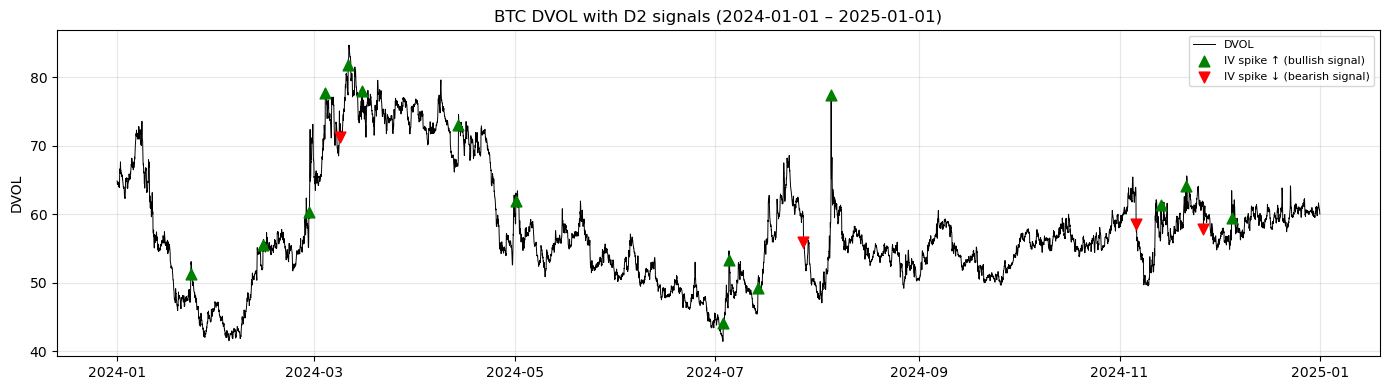

In [3]:
def plot_signals_on_dvol(feat: pd.DataFrame, sigs: pd.DataFrame,
                          definition: str, currency: str,
                          start: str = '2024-01-01', end: str = '2025-01-01'):
    mask = (feat.index >= start) & (feat.index < end)
    f = feat[mask]
    s = sigs[mask][definition]

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(f.index, f['dvol_close'], color='black', lw=0.7, label='DVOL')

    bull = s[s == 1].index
    bear = s[s == -1].index
    ax.scatter(bull, f.loc[bull, 'dvol_close'], marker='^', color='green',
               s=60, zorder=5, label='IV spike ↑ (bullish signal)')
    ax.scatter(bear, f.loc[bear, 'dvol_close'], marker='v', color='red',
               s=60, zorder=5, label='IV spike ↓ (bearish signal)')

    ax.set_title(f'{currency} DVOL with {definition} signals ({start} – {end})')
    ax.set_ylabel('DVOL')
    ax.legend(loc='upper right', fontsize=8)
    plt.tight_layout()
    plt.savefig(f'../data/plots/{currency}_{definition}_signals.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_signals_on_dvol(btc_feat, btc_sigs, 'D1', 'BTC')
plot_signals_on_dvol(btc_feat, btc_sigs, 'D2', 'BTC')

## 3. Signal Timing Analysis — Hour of Day and Day of Week

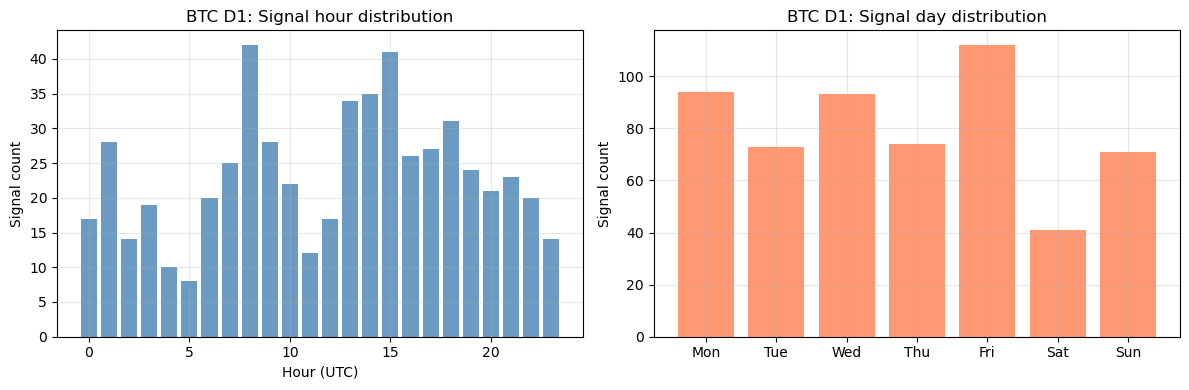

Total events: 558 | Bullish: 352 | Bearish: 206


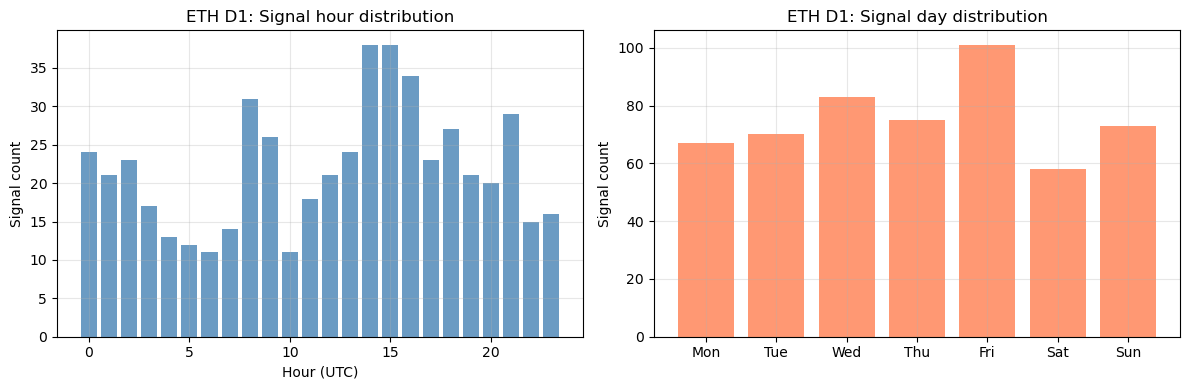

Total events: 527 | Bullish: 334 | Bearish: 193


In [4]:
def timing_analysis(sigs: pd.DataFrame, definition: str, currency: str):
    events = sigs[sigs[definition] != 0].index
    if events.empty:
        print(f'No {definition} events for {currency}')
        return

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Hour of day
    hours = events.hour.value_counts().sort_index()
    axes[0].bar(hours.index, hours.values, color='steelblue', alpha=0.8)
    axes[0].set_xlabel('Hour (UTC)')
    axes[0].set_ylabel('Signal count')
    axes[0].set_title(f'{currency} {definition}: Signal hour distribution')

    # Day of week
    days = events.dayofweek.value_counts().sort_index()
    day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
    axes[1].bar([day_labels[d] for d in days.index], days.values, color='coral', alpha=0.8)
    axes[1].set_ylabel('Signal count')
    axes[1].set_title(f'{currency} {definition}: Signal day distribution')

    plt.tight_layout()
    plt.show()
    print(f'Total events: {len(events)} | Bullish: {(sigs[definition]==1).sum()} | Bearish: {(sigs[definition]==-1).sum()}')

timing_analysis(btc_sigs, 'D1', 'BTC')
timing_analysis(eth_sigs, 'D1', 'ETH')

## 4. Signal Magnitude Distribution

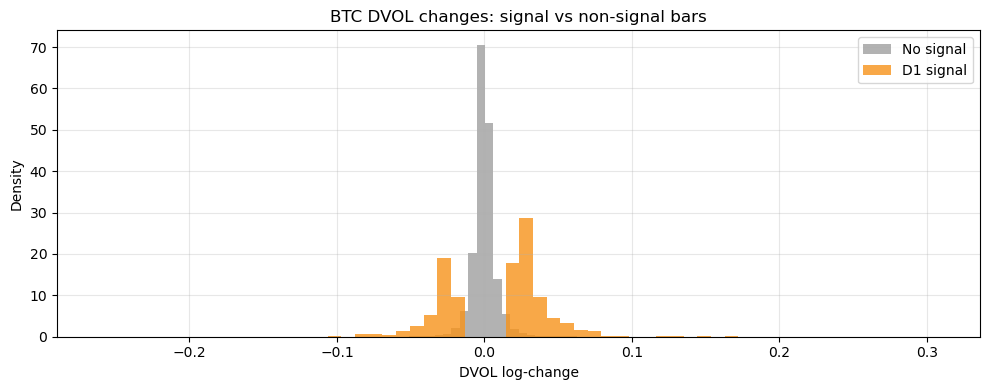

In [5]:
# Distribution of DVOL changes on signal vs non-signal bars
btc_changes = btc_feat['dvol_change'].dropna()
sig_mask = btc_sigs['D1'] != 0

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(btc_changes[~sig_mask], bins=100, alpha=0.6, label='No signal', color='grey', density=True)
ax.hist(btc_changes[sig_mask], bins=30, alpha=0.8, label='D1 signal', color='#f7931a', density=True)
ax.set_xlabel('DVOL log-change')
ax.set_ylabel('Density')
ax.set_title('BTC DVOL changes: signal vs non-signal bars')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Save Signals

Save computed signals to disk for use in downstream notebooks.

In [6]:
from pathlib import Path
sig_dir = Path('../data/signals')
sig_dir.mkdir(exist_ok=True)

btc_sigs.to_parquet(sig_dir / 'BTC_signals.parquet')
eth_sigs.to_parquet(sig_dir / 'ETH_signals.parquet')
btc_feat.to_parquet(sig_dir / 'BTC_features.parquet')
eth_feat.to_parquet(sig_dir / 'ETH_features.parquet')
print('Saved signals and features to data/signals/')

Saved signals and features to data/signals/
